# Intrusion Detection System Using Machine Learning
**Author:** Muhammad Muneer Hussain  
**Date:** 12 November 2025  

---

## 1️⃣ Dataset Selection & Problem Framing
- **Dataset:** `KDDTrain++.csv` — a well-known network intrusion detection dataset containing **125,972 records** and **43 features**.  
- **Problem Type:** Binary Classification  
- **Goal:** Detect whether a network connection is **Normal** or **Attack** based on network behavior.  

---

## 2️⃣ Data Preprocessing & Feature Engineering
- Checked dataset structure, null values, and duplicates (none found).  
- Converted all non-normal outcomes to **“attack”** class for binary labels.  
- Applied **RobustScaler** to scale numeric features.  
- Encoded categorical columns (`protocol_type`, `service`, `flag`) using **one-hot encoding**.  
- Reduced feature dimensions from **122 → 20** using **PCA** for efficiency.  
- Split dataset into **80% training** and **20% testing** sets.  

---

## 3️⃣ Machine Learning Implementation & Outcomes
### 🔹 Models Used
- **Logistic Regression**  
- **Support Vector Machine (SVM)**  
- **Decision Tree Classifier**

### 🔹 Evaluation Metrics
- Accuracy  
- Precision  
- Recall  
- Confusion Matrix  

| Model | Train Accuracy | Test Accuracy | Precision | Recall |
|--------|----------------|----------------|------------|--------|
| Logistic Regression | 88.70% | 88.52% | 85.21% | 91.37% |
| Support Vector Machine (Linear SVC) | 97.20% | 97.04% | 97.64% | 96.01% |
| Decision Tree | 99.99% | 99.85% | 99.84% | 99.84% |

✅ **Best Model:** *Decision Tree Classifier* (Test Accuracy: **99.85%**)  

---

## 4️⃣ Sample Predictions
| Row | Prediction |
|------|-------------|
| 1 | Normal ✅ |
| 2 | Attack 🚨 |
| 3 | Normal ✅ |

---

## 5️⃣ Conclusion
The **Intrusion Detection System (IDS)** was successfully developed using machine learning techniques.  
Among the models tested — Logistic Regression, SVM, and Decision Tree — the **Decision Tree Classifier** achieved the highest performance (99.85% accuracy) and effectively identified malicious traffic, making it suitable for **real-time intrusion detection applications**.

---


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline

## Exploring the dataset

In [ ]:
data_train = pd.read_csv("KDDTrain++.csv")

In [ ]:

data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
data_train.tail(6)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
125966,0,tcp,http,SF,359,375,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,11,0.33,0.09,0.0,0.0,1.00,0.00,0.18,3,255,1.00,0.00,0.33,0.04,0.33,0.0,0.00,0.0,normal,18
125967,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,184,25,1.00,1.00,0.0,0.0,0.14,0.06,0.00,255,25,0.10,0.06,0.00,0.00,1.00,1.0,0.00,0.0,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.00,0.00,0.0,0.0,1.00,0.00,0.00,255,244,0.96,0.01,0.01,0.00,0.00,0.0,0.00,0.0,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.00,0.00,0.0,0.0,1.00,0.00,0.00,255,30,0.12,0.06,0.00,0.00,0.72,0.0,0.01,0.0,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,144,8,1.00,1.00,0.0,0.0,0.06,0.05,0.00,255,8,0.03,0.05,0.00,0.00,1.00,1.0,0.00,0.0,neptune,20
125971,0,tcp,ftp_data,SF,151,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.00,0.00,0.0,0.0,1.00,0.00,0.00,255,77,0.30,0.03,0.30,0.00,0.00,0.0,0.00,0.0,normal,21


In [ ]:
data_train.shape

(125972, 43)

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [ ]:
data_train.isna().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
data_train.duplicated().sum()

np.int64(0)

In [ ]:
data_train.describe().style.background_gradient(cmap='Oranges') \
    .set_properties(**{'font-family': 'Segoe UI', 'text-align': 'center', 'border': '1px solid #ddd'})


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,45567.100824,19779.271433,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,0.001342,0.001103,0.302194,0.012669,0.000413,0.004096,0.000000,0.000008,0.009423,84.108207,27.738093,0.284487,0.282488,0.119959,0.121184,0.660925,0.063053,0.097322,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5870354.480802,4021285.112110,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,0.036603,0.045155,24.399715,0.483937,0.022181,0.099370,0.000000,0.002817,0.096613,114.508828,72.636092,0.446457,0.447024,0.320437,0.323648,0.439624,0.180315,0.259831,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,276.000000,516.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1379963888.000000,1309937401.000000,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
data_train.loc[data_train['outcome'] == "normal", "outcome"] = 'normal'
data_train.loc[data_train['outcome'] != 'normal', "outcome"] = 'attack'

In [ ]:
def pie_plot(df, cols, rows, cols_n):
    fig, axes = plt.subplots(rows, cols_n, figsize=(14, 8))
    axes = axes.ravel()
    for ax, c in zip(axes, cols):
        df[c].value_counts().plot.pie(
            ax=ax, autopct='%1.1f%%', startangle=120,
            colors=sns.color_palette('pastel'), textprops={'fontsize': 9}
        )
        ax.set_title(c, fontsize=11, fontweight='bold')
        ax.set_ylabel('')
        ax.axis('equal')
    for ax in axes[len(cols):]: ax.remove()  # remove empty axes
    plt.tight_layout()
    plt.show()


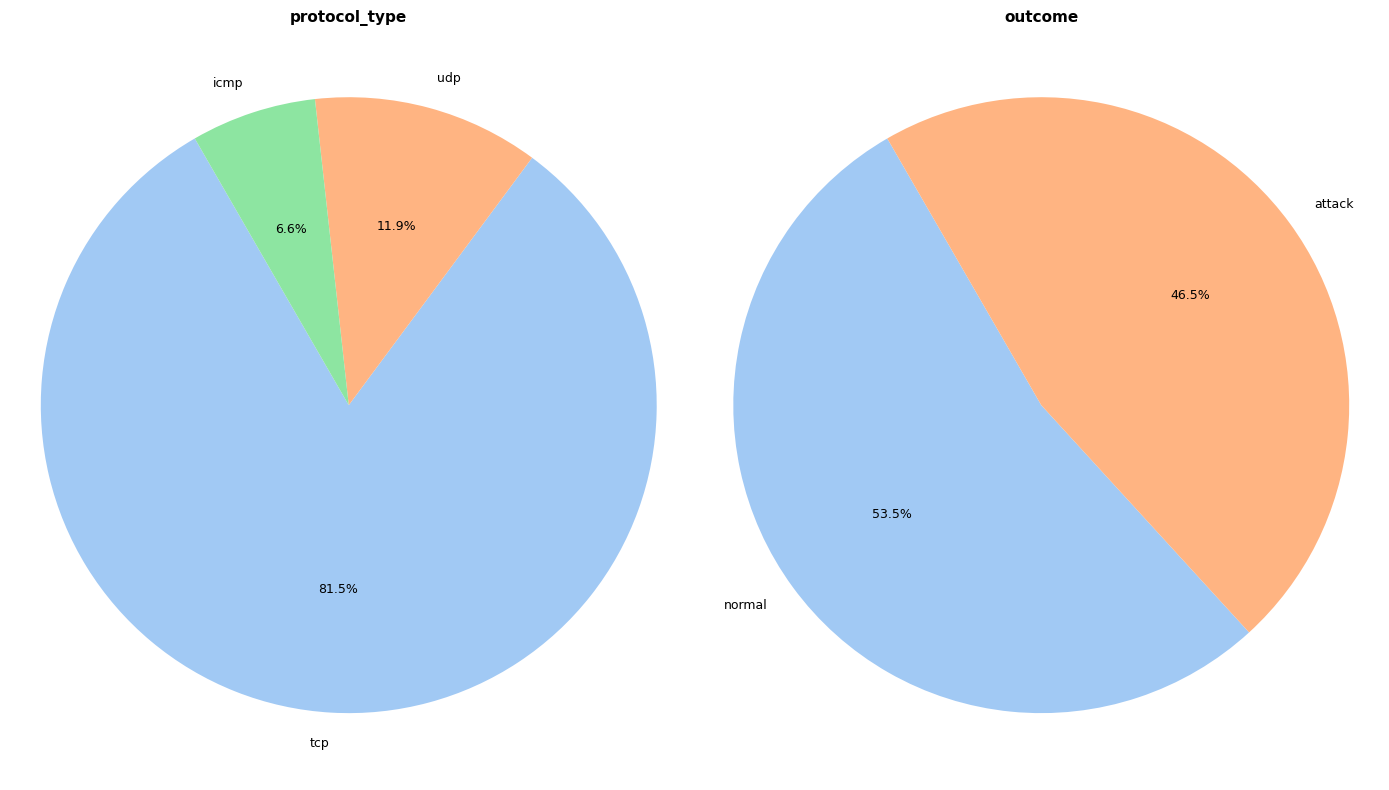

In [ ]:
pie_plot(data_train, ['protocol_type', 'outcome'], 1, 2)

## Preprocessing the data

In [ ]:

def Scaling(df_num, cols):
    std_scaler = RobustScaler()
    std_scaler_temp = std_scaler.fit_transform(df_num)
    std_df = pd.DataFrame(std_scaler_temp, columns =cols)
    return std_df

In [ ]:

cat_cols = ['is_host_login','protocol_type','service','flag','land', 'logged_in','is_guest_login', 'level', 'outcome']
def preprocess(dataframe):
    df_num = dataframe.drop(cat_cols, axis=1)
    num_cols = df_num.columns
    scaled_df = Scaling(df_num, num_cols)

    dataframe.drop(labels=num_cols, axis="columns", inplace=True)
    dataframe[num_cols] = scaled_df[num_cols]

    dataframe.loc[dataframe['outcome'] == "normal", "outcome"] = 0
    dataframe.loc[dataframe['outcome'] != 0, "outcome"] = 1

    dataframe = pd.get_dummies(dataframe, columns = ['protocol_type', 'service', 'flag'])
    return dataframe

In [ ]:
scaled_train = preprocess(data_train)

In [ ]:
scaled_train.dropna(inplace=True)

In [ ]:
x = scaled_train.drop(['outcome', 'level'] , axis = 1).values
y = scaled_train['outcome'].values
y_reg = scaled_train['level'].values

pca = PCA(n_components=20)
pca = pca.fit(x)
x_reduced = pca.transform(x)
print("Number of original features is {} and of reduced features is {}".format(x.shape[1], x_reduced.shape[1]))

y = y.astype('int')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, y, test_size=0.2, random_state=42)
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size=0.2, random_state=42)

Number of original features is 122 and of reduced features is 20


In [ ]:
kernal_evals = dict()
def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    train_accuracy = metrics.accuracy_score(y_train, model.predict(X_train))
    test_accuracy = metrics.accuracy_score(y_test, model.predict(X_test))

    train_precision = metrics.precision_score(y_train, model.predict(X_train))
    test_precision = metrics.precision_score(y_test, model.predict(X_test))

    train_recall = metrics.recall_score(y_train, model.predict(X_train))
    test_recall = metrics.recall_score(y_test, model.predict(X_test))

    kernal_evals[str(name)] = [train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall]
    print("Training Accuracy " + str(name) + " {}  Test Accuracy ".format(train_accuracy*100) + str(name) + " {}".format(test_accuracy*100))
    print("Training Precesion " + str(name) + " {}  Test Precesion ".format(train_precision*100) + str(name) + " {}".format(test_precision*100))
    print("Training Recall " + str(name) + " {}  Test Recall ".format(train_recall*100) + str(name) + " {}".format(test_recall*100))

    actual = y_test
    predicted = model.predict(X_test)
    confusion_matrix = metrics.confusion_matrix(actual, predicted)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['normal', 'attack'])

    fig, ax = plt.subplots(figsize=(7,7))
    ax.grid(False)
    cm_display.plot(ax=ax)

Training Accuracy Logistic Regression 88.70277940403068  Test Accuracy Logistic Regression 88.5255010914864
Training Precesion Logistic Regression 85.1896722939424  Test Precesion Logistic Regression 85.21560574948666
Training Recall Logistic Regression 91.61060208026312  Test Recall Logistic Regression 91.37098822931662


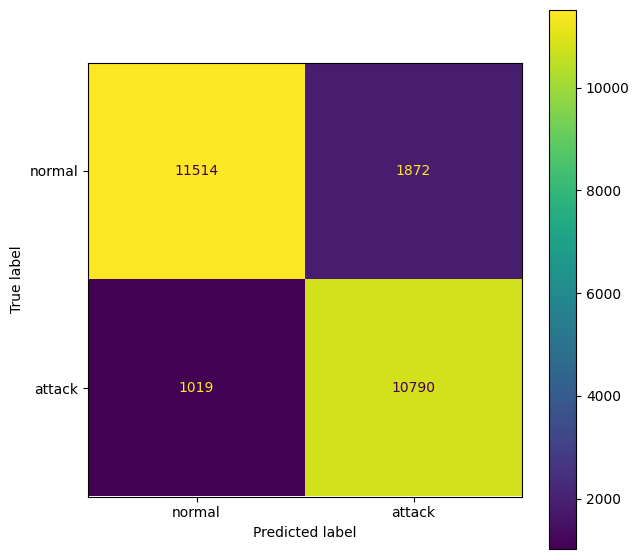

In [ ]:
lr = LogisticRegression().fit(x_train, y_train)
evaluate_classification(lr, "Logistic Regression", x_train, x_test, y_train, y_test)

In [ ]:
lin_svc = svm.LinearSVC().fit(x_train, y_train)

Training Accuracy Linear SVC(LBasedImpl) 97.20372704089226  Test Accuracy Linear SVC(LBasedImpl) 97.04306410001985
Training Precesion Linear SVC(LBasedImpl) 97.89494307421033  Test Precesion Linear SVC(LBasedImpl) 97.64037202893559
Training Recall Linear SVC(LBasedImpl) 96.04664573588775  Test Recall Linear SVC(LBasedImpl) 96.01151663985095


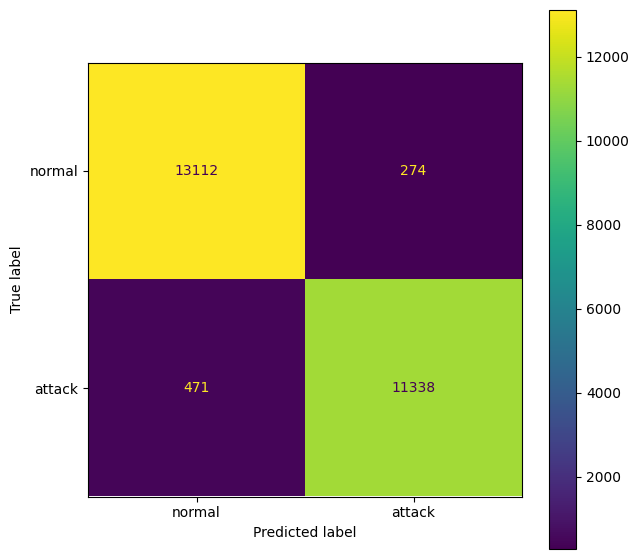

In [ ]:
evaluate_classification(lin_svc, "Linear SVC(LBasedImpl)", x_train, x_test, y_train, y_test)

## Decision Tree


Training Accuracy DecisionTreeClassifier 99.99404626055548  Test Accuracy DecisionTreeClassifier 99.8571145068466
Training Precesion DecisionTreeClassifier 100.0  Test Precesion DecisionTreeClassifier 99.84757388432551
Training Recall DecisionTreeClassifier 99.98718523739348  Test Recall DecisionTreeClassifier 99.84757388432551


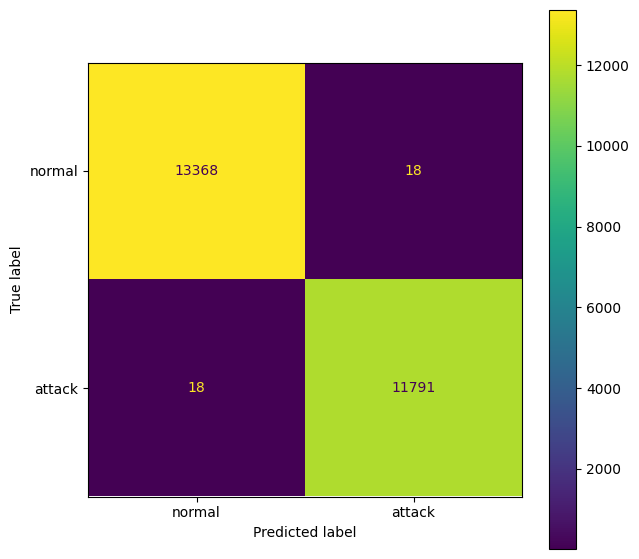

In [ ]:
dt = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)
tdt = DecisionTreeClassifier().fit(x_train, y_train)
evaluate_classification(tdt, "DecisionTreeClassifier", x_train, x_test, y_train, y_test)

In [ ]:

sample_data = pd.DataFrame([
    {'duration': 0, 'protocol_type': 'tcp', 'service': 'http', 'flag': 'SF', 'src_bytes': 181, 'dst_bytes': 5450,
     'land': 0, 'wrong_fragment': 0, 'urgent': 0, 'hot': 0, 'num_failed_logins': 0, 'logged_in': 1,
     'num_compromised': 0, 'root_shell': 0, 'su_attempted': 0, 'num_root': 0, 'num_file_creations': 0,
     'num_shells': 0, 'num_access_files': 0, 'num_outbound_cmds': 0, 'is_host_login': 0, 'is_guest_login': 0,
     'count': 9, 'srv_count': 9, 'serror_rate': 0.0, 'srv_serror_rate': 0.0, 'rerror_rate': 0.0,
     'srv_rerror_rate': 0.0, 'same_srv_rate': 1.0, 'diff_srv_rate': 0.0, 'srv_diff_host_rate': 0.0,
     'dst_host_count': 9, 'dst_host_srv_count': 9, 'dst_host_same_srv_rate': 1.0, 'dst_host_diff_srv_rate': 0.0,
     'dst_host_same_src_port_rate': 1.0, 'dst_host_srv_diff_host_rate': 0.0, 'dst_host_serror_rate': 0.0,
     'dst_host_srv_serror_rate': 0.0, 'dst_host_rerror_rate': 0.0, 'dst_host_srv_rerror_rate': 0.0,
     'outcome': 'normal', 'level': 'low'},

    {'duration': 2, 'protocol_type': 'udp', 'service': 'domain_u', 'flag': 'S0', 'src_bytes': 239, 'dst_bytes': 486,
     'land': 0, 'wrong_fragment': 0, 'urgent': 0, 'hot': 0, 'num_failed_logins': 0, 'logged_in': 0,
     'num_compromised': 0, 'root_shell': 0, 'su_attempted': 0, 'num_root': 0, 'num_file_creations': 0,
     'num_shells': 0, 'num_access_files': 0, 'num_outbound_cmds': 0, 'is_host_login': 0, 'is_guest_login': 0,
     'count': 30, 'srv_count': 15, 'serror_rate': 0.0, 'srv_serror_rate': 0.0, 'rerror_rate': 0.0,
     'srv_rerror_rate': 0.0, 'same_srv_rate': 0.6, 'diff_srv_rate': 0.4, 'srv_diff_host_rate': 0.0,
     'dst_host_count': 32, 'dst_host_srv_count': 20, 'dst_host_same_srv_rate': 0.6, 'dst_host_diff_srv_rate': 0.4,
     'dst_host_same_src_port_rate': 1.0, 'dst_host_srv_diff_host_rate': 0.0, 'dst_host_serror_rate': 0.0,
     'dst_host_srv_serror_rate': 0.0, 'dst_host_rerror_rate': 0.0, 'dst_host_srv_rerror_rate': 0.0,
     'outcome': 'attack', 'level': 'medium'},

    {'duration': 5, 'protocol_type': 'icmp', 'service': 'ecr_i', 'flag': 'SF', 'src_bytes': 1032, 'dst_bytes': 0,
     'land': 0, 'wrong_fragment': 0, 'urgent': 0, 'hot': 0, 'num_failed_logins': 0, 'logged_in': 0,
     'num_compromised': 0, 'root_shell': 0, 'su_attempted': 0, 'num_root': 0, 'num_file_creations': 0,
     'num_shells': 0, 'num_access_files': 0, 'num_outbound_cmds': 0, 'is_host_login': 0, 'is_guest_login': 0,
     'count': 12, 'srv_count': 12, 'serror_rate': 0.0, 'srv_serror_rate': 0.0, 'rerror_rate': 0.0,
     'srv_rerror_rate': 0.0, 'same_srv_rate': 1.0, 'diff_srv_rate': 0.0, 'srv_diff_host_rate': 0.0,
     'dst_host_count': 12, 'dst_host_srv_count': 12, 'dst_host_same_srv_rate': 1.0, 'dst_host_diff_srv_rate': 0.0,
     'dst_host_same_src_port_rate': 1.0, 'dst_host_srv_diff_host_rate': 0.0, 'dst_host_serror_rate': 0.0,
     'dst_host_srv_serror_rate': 0.0, 'dst_host_rerror_rate': 0.0, 'dst_host_srv_rerror_rate': 0.0,
     'outcome': 'normal', 'level': 'low'}
])


In [ ]:
sample_data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,9,9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,normal,low
1,2,udp,domain_u,S0,239,486,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,15,0.0,0.0,0.0,0.0,0.6,0.4,0.0,32,20,0.6,0.4,1.0,0.0,0.0,0.0,0.0,0.0,attack,medium
2,5,icmp,ecr_i,SF,1032,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,12,0.0,0.0,0.0,0.0,1.0,0.0,0.0,12,12,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,normal,low


In [ ]:
processed_sample=preprocess(sample_data)

In [ ]:

train_cols = scaled_train.drop(['outcome', 'level'], axis=1).columns
processed_sample = processed_sample.reindex(columns=train_cols, fill_value=0)

preds = lr.predict(processed_sample.values)

for i, p in enumerate(preds):
    print(f"Row {i+1}: {'Attack 🚨\n' if p == 1 else 'Normal ✅\n'}")


Row 1: Normal ✅

Row 2: Attack 🚨

Row 3: Normal ✅

